In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Завантаження й огляд даних
# Датасет - 50000 відгуків на фільми з IMDB. Дві колонки: текст відгуку (review) і тональність
# (sentiment) - positive або negative. Тональність і є нашою ціллю для класифікації.
df = pd.read_csv("IMDB Dataset.csv")
df.shape

(50000, 2)

In [3]:
# Перші рядки
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Типи, пропуски, дублікати
print(df.dtypes.to_dict())
print("пропусків:", df.isna().sum().sum())
print("дублікатів:", df.duplicated().sum())

{'review': dtype('O'), 'sentiment': dtype('O')}
пропусків: 0
дублікатів: 418


In [5]:
# Баланс класів - позитивних і негативних відгуків порівну, тобто датасет збалансований.
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
# Дивимось по одному прикладу кожного класу (обрізаємо, бо відгуки довгі). Видно, що в тексті є
# HTML-теги на кшталт <br />, які треба буде прибрати на препроцесингу.
for s in ["positive", "negative"]:
    ex = df[df["sentiment"] == s]["review"].iloc[0]
    print(f"[{s}] {ex[:300]} ...")
    print()

[positive] One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

[negative] Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma ...



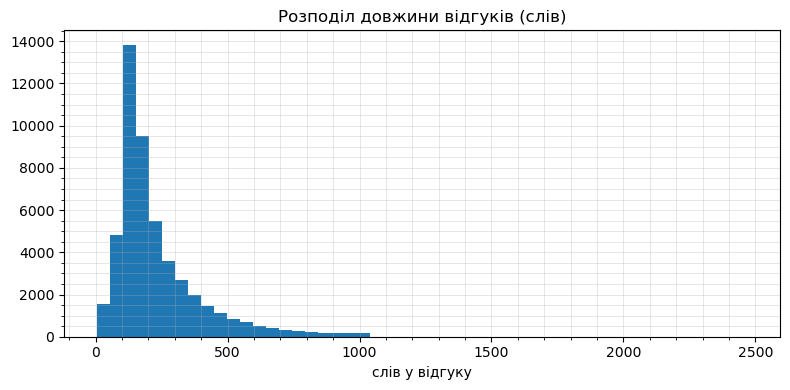

медіана слів: 173 | максимум: 2470


In [7]:
# Розподіл довжини відгуків у словах. Більшість - кілька сотень слів, є довгий хвіст із дуже довгих.
lengths = df["review"].str.split().str.len()
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50)
plt.title("Розподіл довжини відгуків (слів)")
plt.xlabel("слів у відгуку")
plt.tight_layout()
plt.show()
print("медіана слів:", int(lengths.median()), "| максимум:", int(lengths.max()))

In [8]:
# Крок 2. Препроцесинг тексту
# Прибираємо повні дублікати відгуків. Далі чистимо текст: прибираємо HTML-теги, переводимо в нижній
# регістр і лишаємо тільки літери (пунктуацію, цифри й зайві пробіли викидаємо). Так у словнику
# будуть лише слова, а не сміття на кшталт "br" з тегів <br />.
df = df.drop_duplicates(subset="review").reset_index(drop=True)

def clean_text(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["review"].apply(clean_text)
df.shape

(49582, 3)

In [9]:
# Дивимось на прикладі, як змінився текст після чистки.
print("до:   ", df["review"].iloc[0][:200])
print("після:", df["clean"].iloc[0][:200])

до:    One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo
після: one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br


In [10]:
# Кодуємо мітку: negative -> 0, positive -> 1. Це і буде наша ціль y для класифікації.
df["label"] = (df["sentiment"] == "positive").astype(int)
df["label"].value_counts()

label
1    24884
0    24698
Name: count, dtype: int64

In [11]:
# Ділимо на train/test зі stratify, щоб баланс класів зберігся в обох частинах. Вчимось на 80%,
# перевіряємо на 20%, яких модель не бачила.
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["label"], test_size=0.2, random_state=42, stratify=df["label"])
X_train.shape, X_test.shape

((39665,), (9917,))

In [12]:
# Крок 3. Bag-of-Words + класифікатор
# CountVectorizer будує словник слів по train і перетворює кожен відгук у вектор частот слів
# (скільки разів кожне слово зустрілось у відгуку). min_df відкидає дуже рідкісні слова, які
# трапляються менш ніж у 5 відгуках. Стоп-слова навмисно не прибираємо: для тональності важливі
# заперечення (not, no, never) - без них "not good" перетворилося б на "good".
bow = CountVectorizer(min_df=5)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print("розмір словника:", len(bow.vocabulary_), "| матриця train:", X_train_bow.shape)

розмір словника: 33186 | матриця train: (39665, 33186)


In [13]:
# Вчимо логістичну регресію - простий і хороший класифікатор для тексту - на BoW-векторах і
# перевіряємо точність на тесті.
clf_bow = LogisticRegression(max_iter=1000)
clf_bow.fit(X_train_bow, y_train)
acc_bow = clf_bow.score(X_test_bow, y_test)
print(f"Bag-of-Words, test accuracy: {acc_bow:.4f}")

Bag-of-Words, test accuracy: 0.8863


In [14]:
# Крок 4. TF-IDF + класифікатор
# TF-IDF схожий на Bag-of-Words, але замість простої частоти дає слову вагу: часте в цьому відгуку,
# але рідкісне в усьому корпусі слово вважається характернішим і важить більше. Параметри лишаємо ті
# самі, що й для BoW, щоб порівняння було чесним.
tfidf = TfidfVectorizer(min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)
acc_tfidf = clf_tfidf.score(X_test_tfidf, y_test)
print(f"TF-IDF, test accuracy: {acc_tfidf:.4f}")

TF-IDF, test accuracy: 0.8970


In [15]:
# Крок 5. Порівняння BoW vs TF-IDF (+ n-грами)
# Зводимо результати в таблицю. Додатково пробуємо n-грами: крім окремих слів (unigram) беремо ще й
# пари сусідніх слів (bigram). Це частково повертає втрачений порядок слів - наприклад, "not good"
# стає одним токеном, а не двома окремими.
def evaluate(vectorizer_cls, ngram_range):
    vec = vectorizer_cls(min_df=5, ngram_range=ngram_range)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, y_train)
    return len(vec.vocabulary_), clf.score(Xte, y_test)

configs = [
    ("BoW", CountVectorizer, (1, 1)),
    ("TF-IDF", TfidfVectorizer, (1, 1)),
    ("BoW + bigrams", CountVectorizer, (1, 2)),
    ("TF-IDF + bigrams", TfidfVectorizer, (1, 2)),
]
rows = []
for name, cls, ng in configs:
    vocab, acc = evaluate(cls, ng)
    rows.append({"метод": name, "розмір_словника": vocab, "test_accuracy": round(acc, 4)})
results = pd.DataFrame(rows)
results

,метод,розмір_словника,test_accuracy
0,BoW,33186,0.8863
1,TF-IDF,33186,0.8970
2,BoW + bigrams,221190,0.9046
3,TF-IDF + bigrams,221190,0.9029


In [16]:
# Крок 6. Детальна оцінка моделі
# З біграмами BoW і TF-IDF дали майже однаковий результат (~0.90), різниця в межах шуму. Для
# детального звіту беремо TF-IDF з біграмами. Дивимось повний звіт: precision, recall і f1 по
# кожному класу. Класи збалансовані, тож accuracy тут показова.
best_vec = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
X_train_best = best_vec.fit_transform(X_train)
X_test_best = best_vec.transform(X_test)
best_clf = LogisticRegression(max_iter=1000).fit(X_train_best, y_train)
y_pred = best_clf.predict(X_test_best)

print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



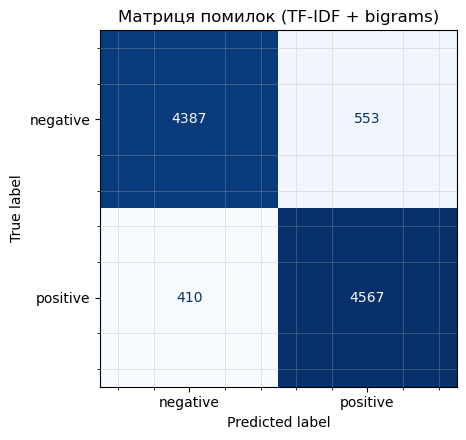

In [17]:
# Матриця помилок: по діагоналі правильні відповіді, поза нею - плутанина. Помилок у обидва боки
# приблизно порівну.
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.grid(False)
plt.title("Матриця помилок (TF-IDF + bigrams)")
plt.tight_layout()
plt.show()

In [18]:
# Кілька прикладів передбачень на тесті: показуємо початок оригінального відгуку, що передбачила
# модель і яка правильна відповідь.
names = {0: "negative", 1: "positive"}
for i, idx in enumerate(X_test.index[:4]):
    print(f"перед: {names[y_pred[i]]} / правда: {names[y_test.loc[idx]]}")
    print("  " + df.loc[idx, "review"][:160] + "...")
    print()

перед: negative / правда: negative
  My wife and I watched this after DVR'ing it off of Encore action this past week. It has to be the worst horror flick either of us had ever seen. Predictable dia...

перед: positive / правда: positive
  I was surprised how much I enjoyed this. Sure it is a bit slow moving in parts, but what else would one expect from Rollin? Also there is plenty of nudity, noth...

перед: positive / правда: positive
  Such a delightful movie! Very heart warming. One can't help falling in love with the character of Gigi. He's adorable as a child and grows into a sensitive arti...

перед: negative / правда: negative
  "La Lupa Mannara" aka. "Werewolf Woman" of 1976 is a film with a highly promising title, but, sadly, the film itself is pretty far away from being a must-see fo...



In [19]:
# Висновки
# - Датасет - 50000 відгуків IMDB, порівну позитивних і негативних. Прибрали 418 дублікатів і
#   почистили текст (HTML-теги, нижній регістр, тільки літери).
# - Задачу вирішували контекстно-незалежними методами: Bag-of-Words (CountVectorizer) і TF-IDF
#   (TfidfVectorizer), класифікатор - логістична регресія.
# - Стоп-слова навмисно не прибирали: для тональності важливі заперечення (not, no, never) - без них
#   not good перетворилося б на good.
# - TF-IDF виявився трохи кращим за BoW (89.7% проти 88.6%): зважування слів за характерністю
#   відкидає шум частих слів.
# - Додавання біграм підняло точність до ~90% - пари сусідніх слів на кшталт not good враховуються
#   як одне ціле, тобто частково повертається порядок слів.
# - З біграмами BoW і TF-IDF дають майже однаковий результат (~90%). Помилки на тесті майже порівну
#   між класами.